In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
credit_df = pd.read_csv('../data/raw/creditcard.csv')
credit_df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


## 1.1 Missing Values

In [3]:
missing_pct_col = credit_df.isnull().mean() * 100
missing_pct_col

Time      0.0
V1        0.0
V2        0.0
V3        0.0
V4        0.0
V5        0.0
V6        0.0
V7        0.0
V8        0.0
V9        0.0
V10       0.0
V11       0.0
V12       0.0
V13       0.0
V14       0.0
V15       0.0
V16       0.0
V17       0.0
V18       0.0
V19       0.0
V20       0.0
V21       0.0
V22       0.0
V23       0.0
V24       0.0
V25       0.0
V26       0.0
V27       0.0
V28       0.0
Amount    0.0
Class     0.0
dtype: float64

### Missing Rows

In [4]:
missing_pct_row = credit_df.isnull().mean(axis=1) * 100
num_rows_to_drop = (missing_pct_row > 30).sum()
num_rows_to_drop

np.int64(0)

* Dropping or immuting rows or columns is not neccessary since no cell contains missing data. 

## 1.2 Duplicate Values

In [5]:
credit_df.duplicated().sum()

np.int64(1081)

* No duplicated rows are found.

## 1.3 Data Types

In [6]:
credit_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

# 2. Exploratory Data Analysis

In [7]:
credit_df.shape

(284807, 31)

In [8]:
credit_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [9]:
credit_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## 2.1  Univariate Analysis

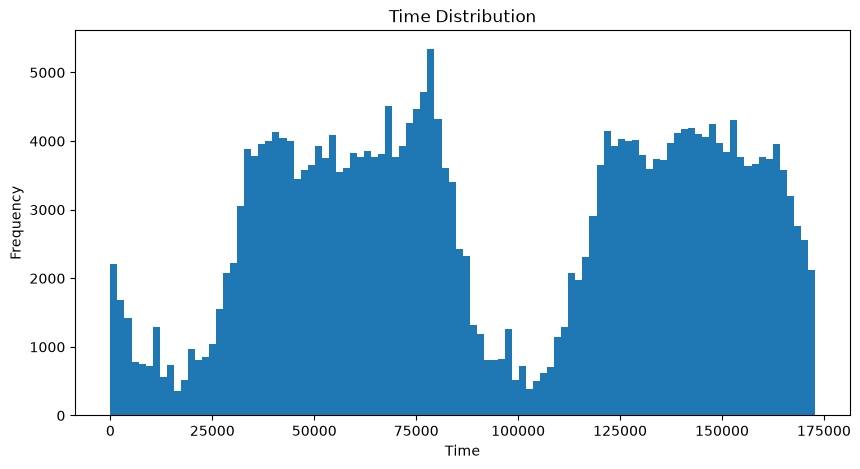

In [10]:
credit_df["Time"].plot.hist(bins=100,figsize=(10,5))
plt.xlabel("Time")
plt.title("Time Distribution")
plt.show()

* Shows two distinct wave-like peaks over time (likely representing daytime activity over 2 consecutive days, with dips during nighttime). Transaction volume follows a clear daily cycle.

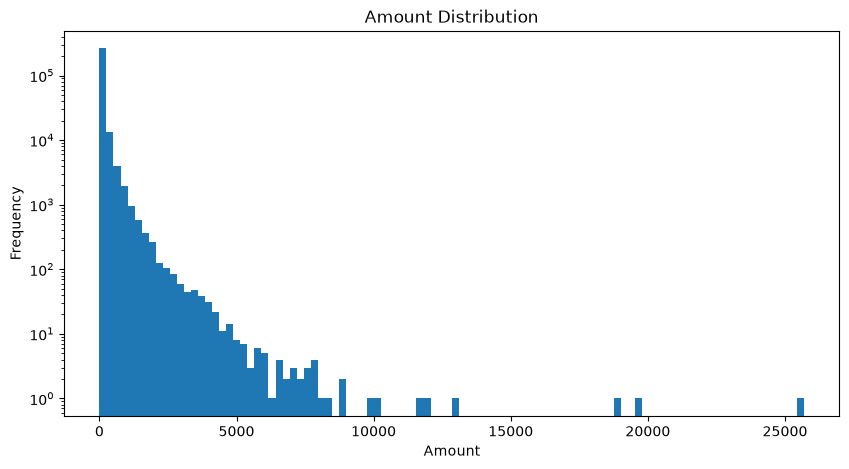

In [11]:
credit_df["Amount"].plot.hist(bins=100,figsize=(10,5))
plt.yscale('log')
plt.xlabel("Amount")
plt.title("Amount Distribution")
plt.show()

* Heavily right-skewed (log scale). The vast majority of transactions are small amounts under $100, while a few extreme outliers reach up to ~25,000.

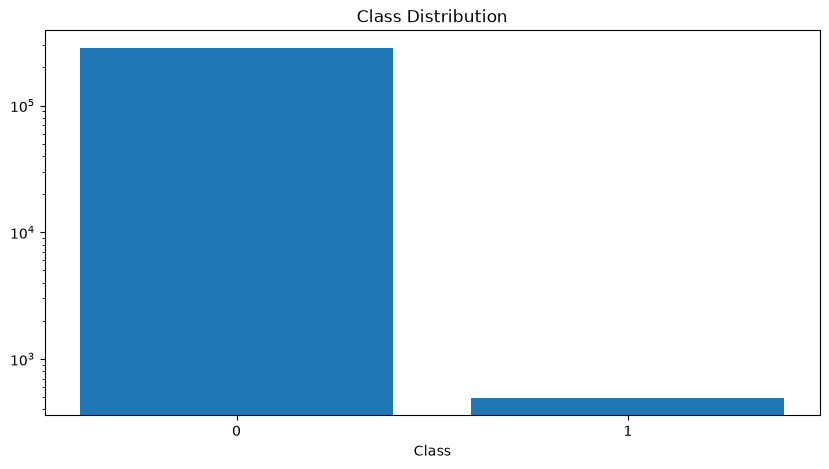

In [12]:
counts = credit_df["Class"].value_counts()

plt.figure(figsize=(10, 5))
plt.yscale('log')

plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Class")
plt.title("Class Distribution")
plt.show()

* Extreme class imbalance. Fraudulent transactions (1) make up a tiny fraction.

## 2.2 Bivariate Analysis

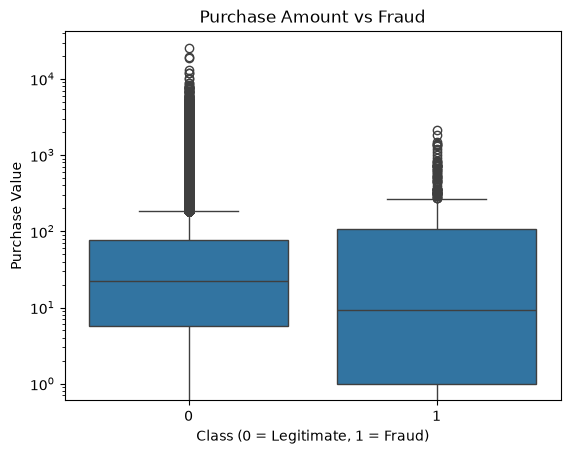

In [13]:
sns.boxplot(x="Class", y="Amount", data=credit_df)
plt.title("Purchase Amount vs Fraud")
plt.yscale('log')

plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Purchase Value")
plt.show()

* Fraudulent transactions (Class 1) show a wider interquartile range spanning from $1 up to ~100, whereas legitimate transactions (Class 0) are concentrated between ~$6 and $80.
* The median purchase amount for fraud is slightly lower (~$10) compared to legitimate purchases (~$22).
* Legitimate transactions have far higher extreme values (reaching over $25,000), while fraudulent transactions reach upto only around ~$2,000.

# 3. Class Imbalance

In [14]:
counts = credit_df["Class"].value_counts()
percentages = credit_df["Class"].value_counts(normalize=True) * 100

print("Legitimate:", counts[0], f"({percentages[0]:.2f}%)")
print("Fraud:", counts[1], f"({percentages[1]:.2f}%)")

Legitimate: 284315 (99.83%)
Fraud: 492 (0.17%)


* There is a very high class imbalance. Nearly 99% of the transactions are legitimate while the remaining 0.1% are fraudlent.

In [15]:
credit_df.to_csv("../data/processed/cleaned_credit_data.csv", index=False)